# Pairs Trading: Mathematical and Statistical Appendix

This notebook serves as the quantitative appendix for the cryptocurrency pairs trading pipeline. 

While the core codebase automatically processes multiple years of data to simulate trading execution, this notebook isolates a single forward-walk cycle. We will manually step through the process of calculating the hedge ratio during a historical formation period (Panel C) and applying those static parameters to an unseen trading period (Panel D) to extract a strictly out-of-sample stationary spread.



In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

plt.style.use('default')


panel_c_df = pd.read_csv('../data/panel_c.csv', index_col='date', parse_dates=True)
panel_d_df = pd.read_csv('../data/panel_d.csv', index_col='date', parse_dates=True)

print("Formation Period (Panel C) Shape:", panel_c_df.shape)
print("Trading Period (Panel D) Shape:", panel_d_df.shape)

Formation Period (Panel C) Shape: (181, 4)
Trading Period (Panel D) Shape: (184, 4)


## 1. Formation Period (In-Sample Validation)

A common flaw is assuming that highly correlated assets are safe to trade. Correlation only measures directional similarity. To execute a mean-reversion strategy, we must test for statistical cointegration. We need to find a linear combination of two assets that results in a stationary time series.

We use the formation period (Panel C) to run an Ordinary Least Squares (OLS) regression between Bitcoin (BTC) and Ethereum (ETH) to find the optimal hedge ratio. We then apply the Augmented Dickey-Fuller (ADF) test to the residuals to validate stationarity.

In [ ]:
independent_x = 'BTC/USDT'
dependent_y = 'ETH/USDT'

X_c = sm.add_constant(panel_c_df[independent_x])
y_c = panel_c_df[dependent_y]

model = sm.OLS(y_c, X_c).fit()
historical_beta = model.params[independent_x]

print(f"Optimal Beta Hedge Ratio (Calculated from Panel C): {historical_beta:.4f}")


spread_c = panel_c_df[dependent_y] - (panel_c_df[independent_x] * historical_beta)

adf_result = adfuller(spread_c)
p_value = adf_result[1]

print(f"ADF Test p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: The spread is stationary in-sample. The pair is validated for trading.")
    

historical_std = spread_c.std()

Optimal Beta Hedge Ratio (Calculated from Panel C): 0.0255
ADF Test p-value: 0.0327
Conclusion: The spread is stationary in-sample. The pair is validated for trading.


## 2. The Trading Period (Out-of-Sample Execution)

Because the ADF test confirmed the BTC/ETH spread was stationary during the formation period, we carry those statistical parameters forward. 

To prevent look-ahead bias, we apply the historical beta and historical standard deviation from Panel C to the new, unseen price data in Panel D. This generates a valid out-of-sample spread. If this new spread expands beyond the historical +1 standard deviation, the algorithm shorts the spread. If it compresses below -1 standard deviation, it longs the spread.

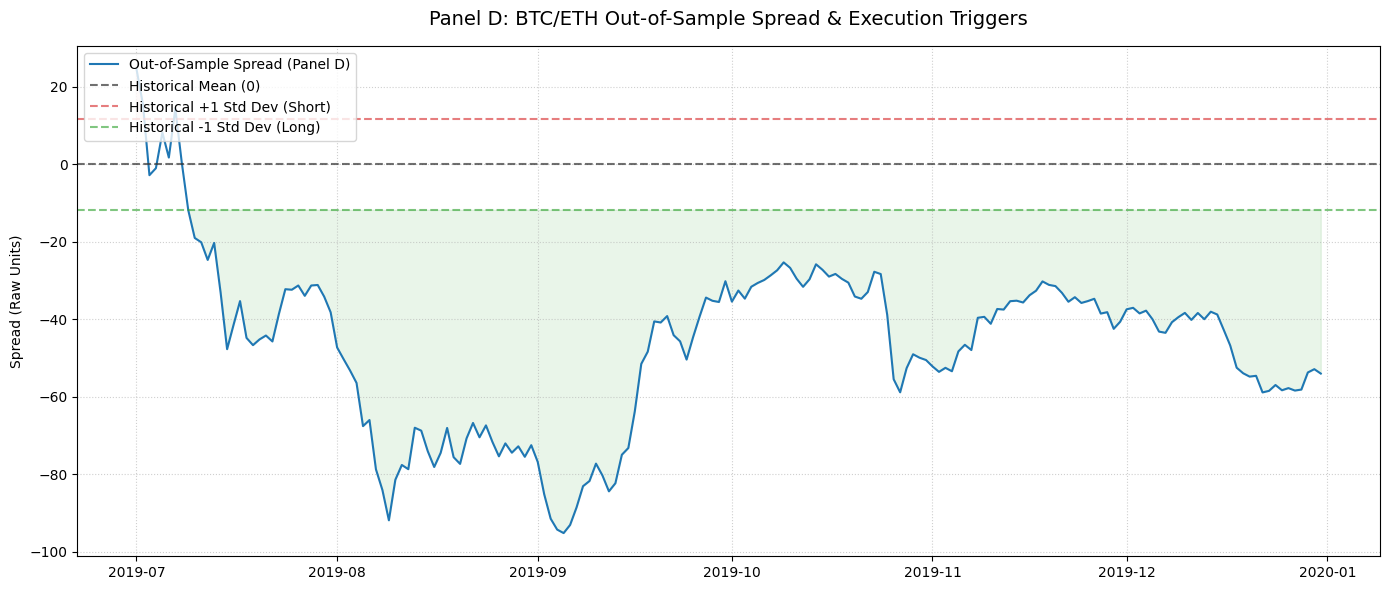

In [ ]:
out_of_sample_spread = panel_d_df[dependent_y] - (panel_d_df[independent_x] * historical_beta)

fig, ax = plt.subplots(figsize=(14, 6), facecolor='#ffffff')


ax.plot(panel_d_df.index, out_of_sample_spread, color='#1f77b4', linewidth=1.5, label='Out-of-Sample Spread (Panel D)')

# Plot the statistical bands generated entirely from Panel C
ax.axhline(0, color='#333333', linestyle='--', alpha=0.7, label='Historical Mean (0)')
ax.axhline(historical_std, color='#d62728', linestyle='--', alpha=0.6, label='Historical +1 Std Dev (Short)')
ax.axhline(-historical_std, color='#2ca02c', linestyle='--', alpha=0.6, label='Historical -1 Std Dev (Long)')

# Add shading for active trading zones
ax.fill_between(panel_d_df.index, out_of_sample_spread, historical_std, 
                 where=(out_of_sample_spread > historical_std), color='#d62728', alpha=0.1)
ax.fill_between(panel_d_df.index, out_of_sample_spread, -historical_std, 
                 where=(out_of_sample_spread < -historical_std), color='#2ca02c', alpha=0.1)

ax.set_title('Panel D: BTC/ETH Out-of-Sample Spread & Execution Triggers', fontsize=14, pad=15)
ax.set_ylabel('Spread (Raw Units)')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left', frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

## 3. Extending the Framework

The logic demonstrated above is executed programmatically across all possible combinations of major assets (BTC, ETH, LTC, NEO) in the `main.py`  script. 

By calculating parameters during a six-month formation window and simulating execution in the subsequent six-month trading window, the primary pipeline ensures that simulated capital is only deployed based on strictly out-of-sample mathematical relationships.